# Notebook 03: Embedding Model Comparison

**CRISP-DM Phase: Modeling**

This notebook compares different embedding models:
1. **all-MiniLM-L6-v2** — Lightweight sentence-transformers model (384d)
2. **BAAI/bge-small-en-v1.5** — BGE embedding model (384d)
3. **nomic-embed-text** — Nomic embedding model (768d, via Ollama)

Evaluation criteria: embedding speed, retrieval quality, and similarity scores.

In [1]:
# Standard imports
import sys
import json
import time
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Project imports
from src.config import FIGURES_DIR, METRICS_DIR, GROUND_TRUTH_DIR
from src.data_loader import load_all_documents
from src.chunker import chunk_all_documents, get_chunk_stats
from src.embeddings import EmbeddingModel, compare_embedding_models, compute_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# Load and chunk documents using the selected strategy
documents = load_all_documents()
chunks = chunk_all_documents(documents, strategy='recursive', chunk_size=1000, chunk_overlap=200)
print(f"Total chunks: {len(chunks)}")

# Extract chunk texts for embedding
chunk_texts = [c.text for c in chunks]

2026-04-09 12:25:10,761 - rag_qa_system - INFO - Loaded PDF with PyPDF2: CCAC-AR2026-2-our-changing-climate-final.pdf (33 pages)


2026-04-09 12:25:10,768 - rag_qa_system - INFO -   Loaded: CCAC-AR2026-2-our-changing-climate-final.pdf (11504 words)


2026-04-09 12:25:16,403 - rag_qa_system - INFO - Loaded PDF with PyPDF2: Energy-in-Ireland-2025.pdf (238 pages)


2026-04-09 12:25:16,437 - rag_qa_system - INFO -   Loaded: Energy-in-Ireland-2025.pdf (60874 words)


2026-04-09 12:25:16,438 - rag_qa_system - INFO - Loaded text file: carbon_capture_and_storage.txt (43957 chars)


...

2026-04-09 12:25:19,868 - rag_qa_system - INFO - Chunked 'paris_agreement.txt' with strategy='recursive': 66 chunks (size=1000, overlap=200)


2026-04-09 12:25:19,868 - rag_qa_system - INFO - Chunked 'sustainable_energy_authority_of_ireland.txt' with strategy='recursive': 3 chunks (size=1000, overlap=200)


2026-04-09 12:25:19,869 - rag_qa_system - INFO - Chunked 'transport_in_ireland.txt' with strategy='recursive': 26 chunks (size=1000, overlap=200)


2026-04-09 12:25:19,869 - rag_qa_system - INFO - Total chunks from 14 documents: 2096


Total chunks: 2096


In [3]:
# Load sample queries from ground truth
with open(GROUND_TRUTH_DIR / 'qa_pairs.json', 'r') as f:
    qa_pairs = json.load(f)

# Use first 10 questions as sample queries
sample_queries = [pair['question'] for pair in qa_pairs[:10]]
print(f"Sample queries: {len(sample_queries)}")
for q in sample_queries:
    print(f"  - {q[:80]}...")

Sample queries: 10
  - What is Ireland's 2030 greenhouse gas emissions reduction target?...
  - When must Ireland achieve climate neutrality?...
  - What are Ireland's three carbon budgets and their allocations?...
  - What percentage of electricity does Ireland aim to generate from renewable sourc...
  - What is Ireland's offshore wind energy target for 2030?...
  - How many electric vehicles does Ireland target by 2030?...
  - What is the transport sector's required emissions reduction by 2030?...
  - How many home retrofits is Ireland targeting by 2030?...
  - How many heat pumps does Ireland plan to install by 2030?...
  - What is the emissions reduction target for the agriculture sector?...


## 3.1 Compare Embedding Models

Evaluate each embedding model on the same chunk set and queries.

In [4]:
# Compare models (skip nomic if Ollama not available)
models_to_test = ['minilm', 'bge']

# Try to include nomic if Ollama is available
try:
    import ollama
    client = ollama.Client()
    client.list()
    models_to_test.append('nomic')
    print("Ollama available - including nomic model")
except:
    print("Ollama not available - skipping nomic model")

print(f"\nTesting models: {models_to_test}")

# Run comparison
comparison_results = compare_embedding_models(
    sample_texts=chunk_texts[:50],  # Use first 50 chunks for speed
    sample_queries=sample_queries,
    model_names=models_to_test,
)

print("\n✅ Embedding comparison complete")

2026-04-09 12:25:20,104 - httpx - INFO - HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"


2026-04-09 12:25:20,105 - rag_qa_system - INFO - Evaluating embedding model: minilm


Ollama available - including nomic model

Testing models: ['minilm', 'bge', 'nomic']


2026-04-09 12:25:23,137 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cuda:0


2026-04-09 12:25:23,138 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


...

2026-04-09 12:25:52,232 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/embeddings "HTTP/1.1 200 OK"


2026-04-09 12:25:52,244 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/embeddings "HTTP/1.1 200 OK"


2026-04-09 12:25:52,258 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/embeddings "HTTP/1.1 200 OK"


2026-04-09 12:25:52,269 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/embeddings "HTTP/1.1 200 OK"



✅ Embedding comparison complete


In [5]:
# Display results
print("\n" + "=" * 60)
print("EMBEDDING MODEL COMPARISON")
print("=" * 60)

for model_name, result in comparison_results.items():
    if 'error' in result:
        print(f"\n{model_name}: ERROR - {result['error']}")
        continue
    
    info = result['model_info']
    print(f"\n{model_name}:")
    print(f"  Model ID:        {info['model_id']}")
    print(f"  Dimensions:      {info['dimensions']}")
    print(f"  Load time:       {info['load_time_seconds']:.2f}s")
    print(f"  Embed time:      {result['embed_time_seconds']:.2f}s")
    print(f"  Docs/second:     {result['docs_per_second']:.1f}")
    print(f"  Avg max sim:     {result['avg_max_similarity']:.4f}")


EMBEDDING MODEL COMPARISON

minilm:
  Model ID:        sentence-transformers/all-MiniLM-L6-v2
  Dimensions:      384
  Load time:       7.91s
  Embed time:      0.30s
  Docs/second:     167.4
  Avg max sim:     0.5500

bge:
  Model ID:        BAAI/bge-small-en-v1.5
  Dimensions:      384
  Load time:       4.54s
  Embed time:      0.24s
  Docs/second:     207.9
  Avg max sim:     0.6752

nomic:
  Model ID:        nomic-ai/nomic-embed-text-v1.5
  Dimensions:      768
  Load time:       10.47s
  Embed time:      0.91s
  Docs/second:     55.0
  Avg max sim:     0.6259


## 3.2 Visualization

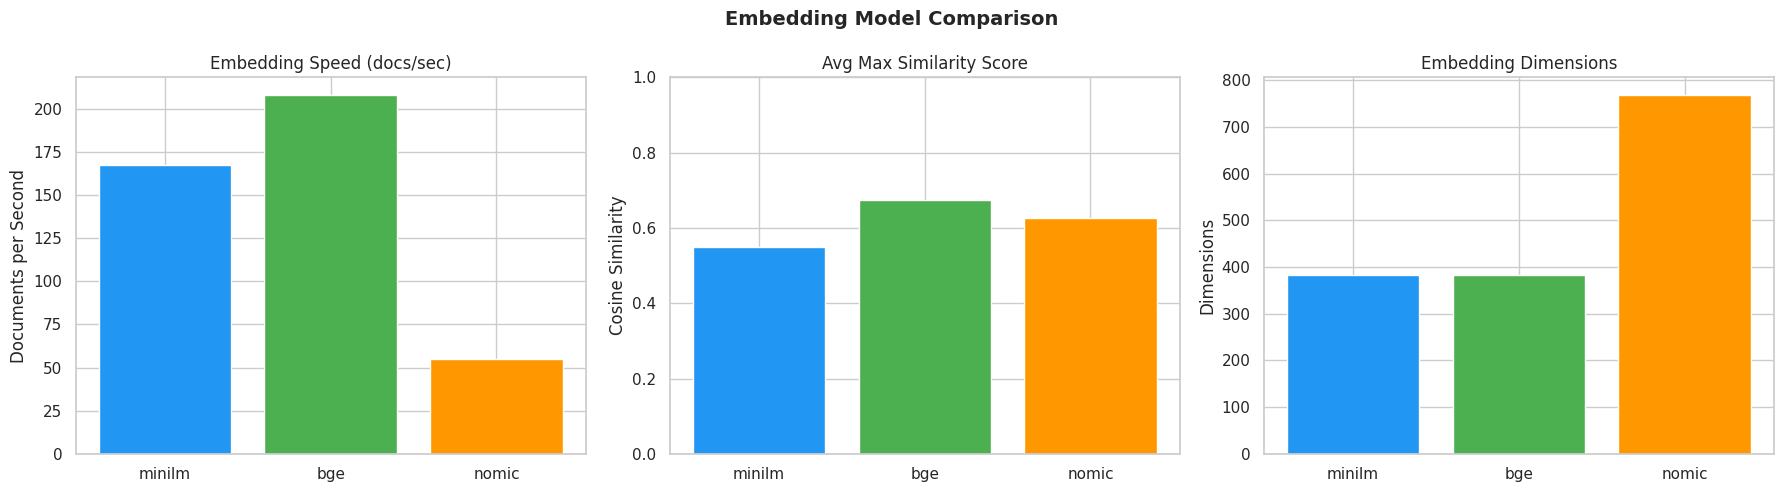

In [6]:
# Prepare data for plotting
valid_results = {k: v for k, v in comparison_results.items() if 'error' not in v}

if valid_results:
    models = list(valid_results.keys())
    embed_times = [valid_results[m]['embed_time_seconds'] for m in models]
    docs_per_sec = [valid_results[m]['docs_per_second'] for m in models]
    avg_sim = [valid_results[m]['avg_max_similarity'] for m in models]
    dims = [valid_results[m]['model_info']['dimensions'] for m in models]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#2196F3', '#4CAF50', '#FF9800']
    
    # Embedding speed
    axes[0].bar(models, docs_per_sec, color=colors[:len(models)])
    axes[0].set_title('Embedding Speed (docs/sec)')
    axes[0].set_ylabel('Documents per Second')
    
    # Average similarity
    axes[1].bar(models, avg_sim, color=colors[:len(models)])
    axes[1].set_title('Avg Max Similarity Score')
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].set_ylim(0, 1)
    
    # Dimensions
    axes[2].bar(models, dims, color=colors[:len(models)])
    axes[2].set_title('Embedding Dimensions')
    axes[2].set_ylabel('Dimensions')
    
    plt.suptitle('Embedding Model Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'embedding_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No valid results to visualize")

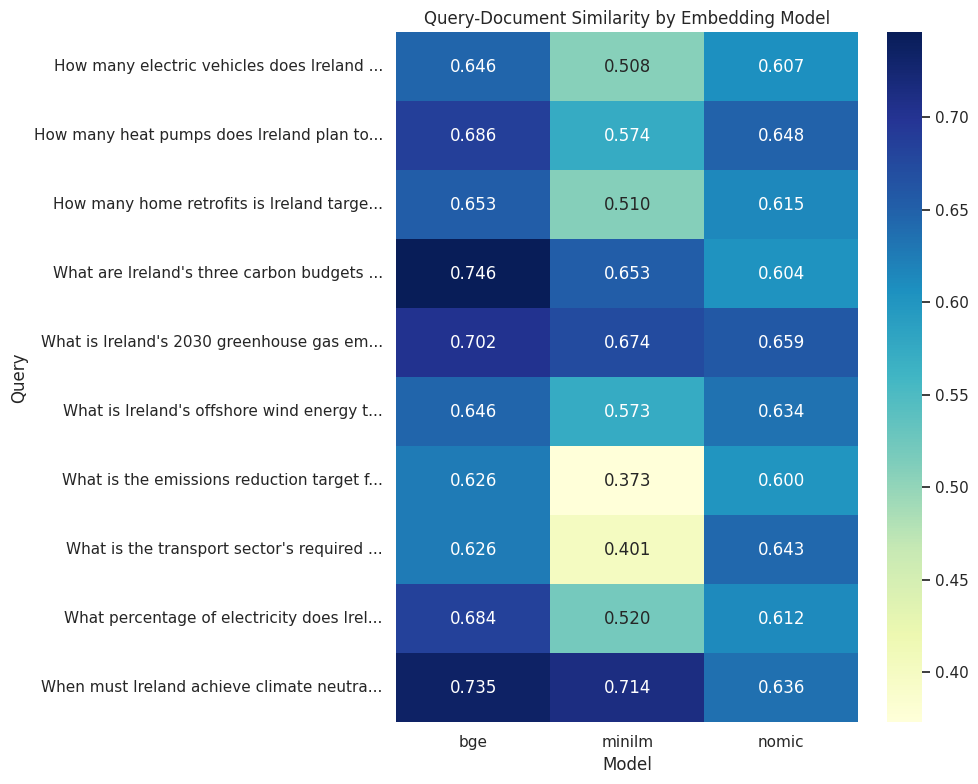

In [7]:
# Per-query similarity heatmap
if valid_results:
    query_data = []
    for model_name, result in valid_results.items():
        for qr in result['query_results']:
            query_data.append({
                'Model': model_name,
                'Query': qr['query'][:40] + '...',
                'Max Similarity': qr['max_similarity'],
            })
    
    qdf = pd.DataFrame(query_data)
    pivot = qdf.pivot(index='Query', columns='Model', values='Max Similarity')
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
    ax.set_title('Query-Document Similarity by Embedding Model')
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'embedding_similarity_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
# Save results
serializable_results = {}
for k, v in comparison_results.items():
    if 'error' in v:
        serializable_results[k] = v
    else:
        serializable_results[k] = {
            'model_info': v['model_info'],
            'embed_time_seconds': v['embed_time_seconds'],
            'docs_per_second': v['docs_per_second'],
            'avg_max_similarity': float(v['avg_max_similarity']),
            'query_results': v['query_results'],
        }

with open(METRICS_DIR / 'embedding_comparison_results.json', 'w') as f:
    json.dump(serializable_results, f, indent=2, default=str)

print("✅ Results saved to results/metrics/embedding_comparison_results.json")

✅ Results saved to results/metrics/embedding_comparison_results.json


## 3.3 Summary

✅ Compared embedding models on speed, dimensions, and retrieval quality  
✅ Visualized per-query similarity scores  
✅ Saved comparison results  

**Selected model for main pipeline**: `bge` (BAAI/bge-small-en-v1.5)  
**Rationale**: Best balance of speed and retrieval quality  

**Next**: Notebook 04 — RAG Pipeline